In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Practical 5 Social_Network_Ads.csv')

# Display the head of the DataFrame
print('DataFrame Head:')
print(df.head())
print('\n')

# Display descriptive statistics of the DataFrame
print('DataFrame Description:')
print(df.describe())
print('\n')

# Display information about the DataFrame
print('DataFrame Info:')
df.info()

DataFrame Head:
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


DataFrame Description:
            User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  400.000000       400.000000  400.000000
mean   1.569154e+07   37.655000     69742.500000    0.357500
std    7.165832e+04   10.482877     34096.960282    0.479864
min    1.556669e+07   18.000000     15000.000000    0.000000
25%    1.562676e+07   29.750000     43000.000000    0.000000
50%    1.569434e+07   37.000000     70000.000000    0.000000
75%    1.575036e+07   46.000000     88000.000000    1.000000
max    1.581524e+07   60.000000    150000.000000    1.000000


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Da

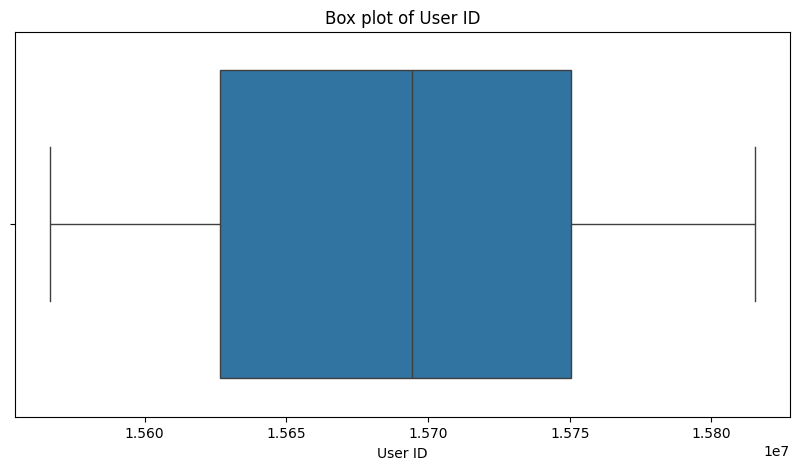

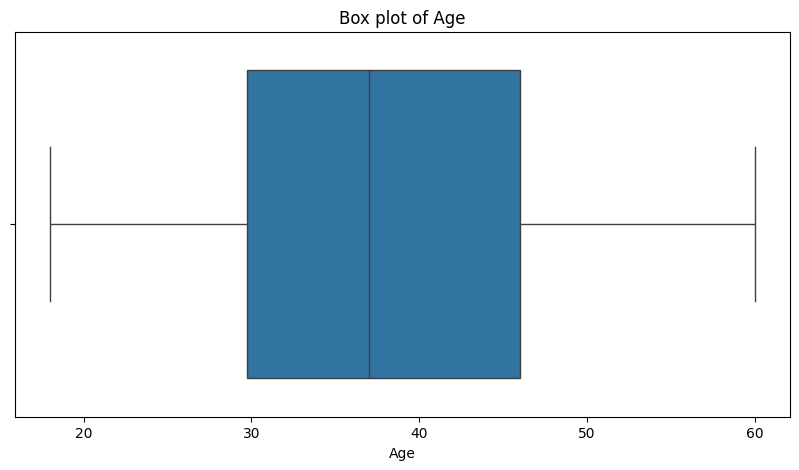

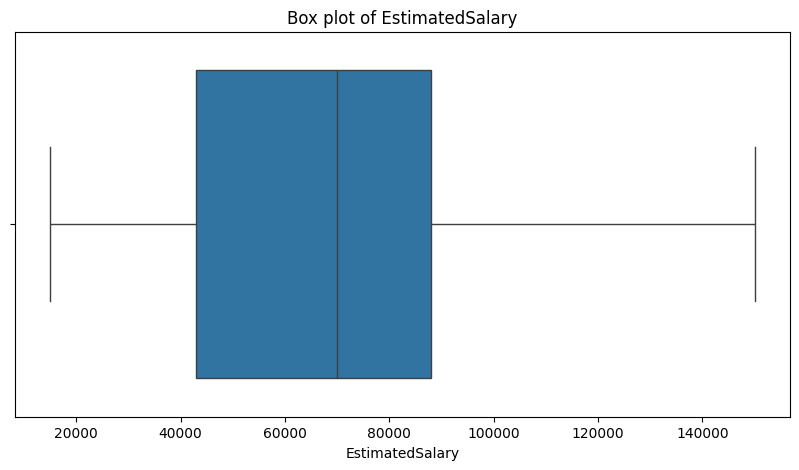

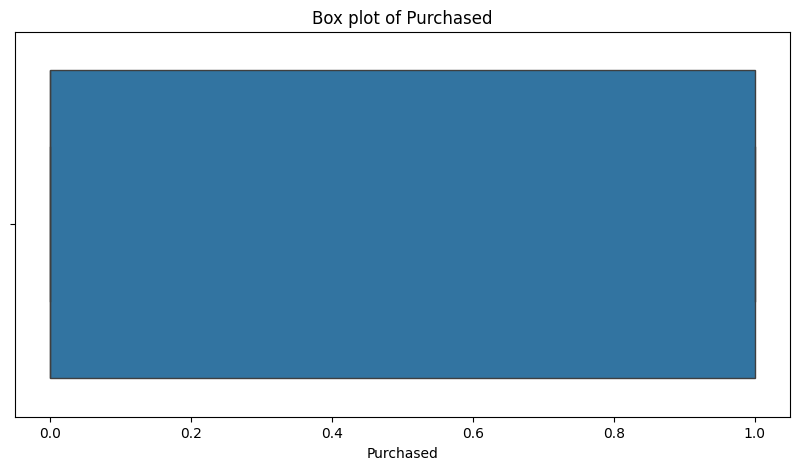

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
for column in df.columns:
  if df[column].dtype in ['float64','int64']:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[column])
    plt.title(f"Box plot of {column}")
    plt.xlabel(column)
    plt.show()

### Data Preprocessing

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

df_processed = df.drop('User ID', axis=1)


le = LabelEncoder()

# Fit and transform the 'Gender' column
df_processed['Gender'] = le.fit_transform(df_processed['Gender'])

# Check the mapping: 0 for Female, 1 for Male
# This is based on fit_transform on ['Female', 'Male'], which assigns 0 to the first unique value encountered and 1 to the second.
# If 'Female' comes before 'Male' alphabetically, then Female=0, Male=1.
# Let's confirm
print("Gender mapping:")
for i, item in enumerate(le.classes_):
    print(f"{item}: {i}")

# Define X (features) and y (target)
X = df_processed[['Gender', 'Age', 'EstimatedSalary']]
y = df_processed['Purchased']

# Split the dataset into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Gender mapping:
Female: 0
Male: 1

Shape of X_train: (320, 3)
Shape of X_test: (80, 3)
Shape of y_train: (320,)
Shape of y_test: (80,)


### Feature Scaling and Model Training

In [6]:
# Feature Scaling
# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Logistic Regression model
classifier = LogisticRegression(random_state=42)
classifier.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Model Evaluation

Accuracy: 0.8875
Error Rate: 0.1125
Precision: 0.9130
Recall: 0.7500
F1-Score: 0.8235

Confusion Matrix (textual):
 [[50  2]
 [ 7 21]]

True Positives (TP): 21
True Negatives (TN): 50
False Positives (FP): 2
False Negatives (FN): 7

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80



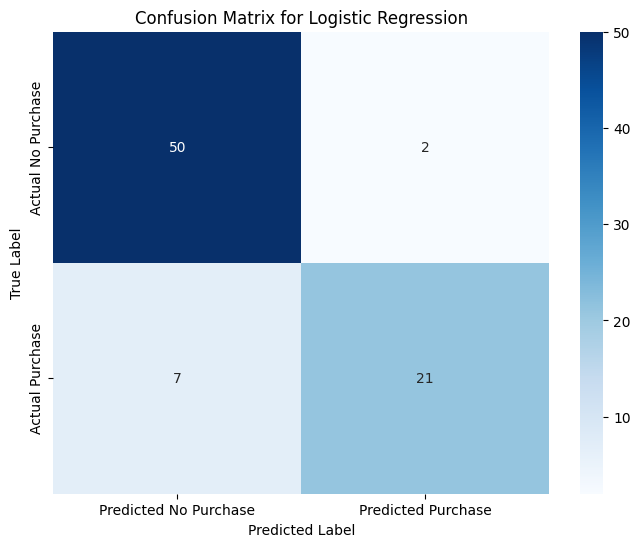

In [7]:
# Make predictions on the test set
y_pred = classifier.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (textual):\n", cm)

# Extracting TP, TN, FP, FN
TN, FP, FN, TP = cm.ravel()

print(f"\nTrue Positives (TP): {TP}")
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visualizing the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Purchase', 'Predicted Purchase'],
            yticklabels=['Actual No Purchase', 'Actual Purchase'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()